In [1]:
# Cell 1
%matplotlib inline
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore', message='.*SQLAlchemy.*', category=UserWarning)

sys.path.insert(0, '../../../..')
import scripts.shared.db_utils
from scripts.shared.db_utils import db_connect

conn = db_connect()
print('connected')

connected


## Step 1 — Confirm monthly columns exist in basin06

In [3]:
# Cell 2 — define monthly column names
MONTHS      = [f'{i:02d}' for i in range(1, 13)]
PRECIP_COLS = [f'pre_mm_s{m}' for m in MONTHS]
TEMP_COLS   = [f'tmp_dc_s{m}' for m in MONTHS]
print('precip:', PRECIP_COLS)
print('temp:  ', TEMP_COLS)

precip: ['pre_mm_s01', 'pre_mm_s02', 'pre_mm_s03', 'pre_mm_s04', 'pre_mm_s05', 'pre_mm_s06', 'pre_mm_s07', 'pre_mm_s08', 'pre_mm_s09', 'pre_mm_s10', 'pre_mm_s11', 'pre_mm_s12']
temp:   ['tmp_dc_s01', 'tmp_dc_s02', 'tmp_dc_s03', 'tmp_dc_s04', 'tmp_dc_s05', 'tmp_dc_s06', 'tmp_dc_s07', 'tmp_dc_s08', 'tmp_dc_s09', 'tmp_dc_s10', 'tmp_dc_s11', 'tmp_dc_s12']


## Step 2 — Fetch test city monthly profiles

Querying `public.basin06` directly (not the view — monthly cols not in view yet).  
Temperature divided by 10 here; stored ×10 in DB.

In [4]:
# Cell 3 — pull monthly data for test cities

TEST_CITIES = {
    'Rome':     (41.9,    12.5),
    'Delhi':    (28.6,    77.2),
    'London':   (51.5,   -0.1),
    'Timbuktu': (16.8167, -2.9833),
}

rows = []
for city, (lat, lon) in TEST_CITIES.items():
    cols_sql = ', '.join(f'b.{c}' for c in PRECIP_COLS + TEMP_COLS)
    sql = f"""
    SELECT {cols_sql}
    FROM public.basin06 b
    WHERE ST_Covers(b.geom, ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326))
    ORDER BY ST_Area(b.geom::geography) ASC
    LIMIT 1
    """
    df = pd.read_sql(sql, conn)
    df.insert(0, 'city', city)
    rows.append(df)

df_raw = pd.concat(rows, ignore_index=True).set_index('city')

# Divide temperature by 10 (stored ×10)
for c in TEMP_COLS:
    df_raw[c] = df_raw[c] / 10.0

print("Monthly precip (mm):")
print(df_raw[PRECIP_COLS].round(1).to_string())
print("\nMonthly temp (°C):")
print(df_raw[TEMP_COLS].round(1).to_string())

Monthly precip (mm):
          pre_mm_s01  pre_mm_s02  pre_mm_s03  pre_mm_s04  pre_mm_s05  pre_mm_s06  pre_mm_s07  pre_mm_s08  pre_mm_s09  pre_mm_s10  pre_mm_s11  pre_mm_s12
city                                                                                                                                                    
Rome              65          65          64          69          62          59          39          54          76          95         106          82
Delhi             18           9          15           3           9          37         203         240         120          31           4           7
London            63          42          52          47          53          54          48          58          59          62          66          67
Timbuktu           0           0           0           1           4          17          54          78          32           4           0           0

Monthly temp (°C):
          tmp_dc_s01  tmp_dc_s02  tmp_dc_

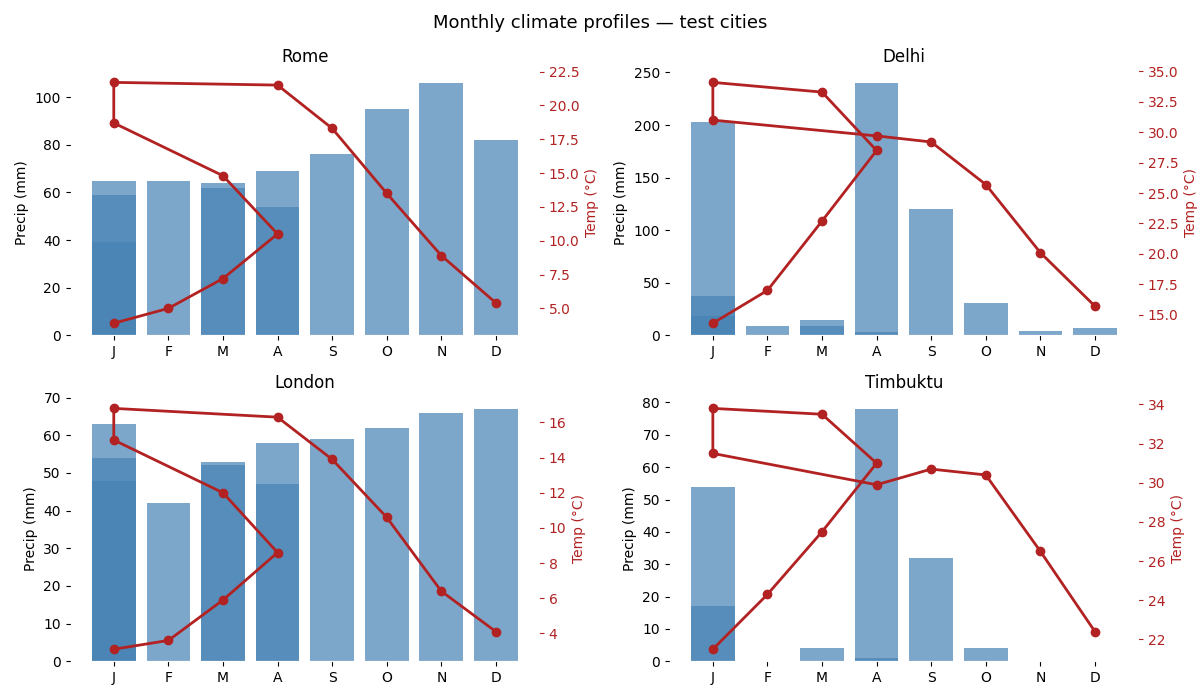

In [5]:
# Cell 4 — monthly profile plots (visual check)
# Precip bars (left axis) + temp line (right axis) for each city.

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.patch.set_facecolor('white')

for ax, city in zip(axes.flat, TEST_CITIES):
    ax.set_facecolor('white')
    precip = df_raw.loc[city, PRECIP_COLS].values
    temp   = df_raw.loc[city, TEMP_COLS].values

    bars = ax.bar(month_labels, precip, color='steelblue', alpha=0.7, label='Precip (mm)')
    ax2  = ax.twinx()
    ax2.plot(month_labels, temp, color='firebrick', marker='o', linewidth=2, label='Temp (°C)')
    ax2.tick_params(colors='firebrick')

    ax.set_title(city, color='black', fontsize=12)
    ax.set_ylabel('Precip (mm)', color='black')
    ax2.set_ylabel('Temp (°C)', color='firebrick')
    ax.tick_params(colors='black')

fig.suptitle('Monthly climate profiles — test cities', color='black', fontsize=13)
fig.tight_layout()

out_path = Path(scripts.shared.db_utils.__file__).parent.parent.parent / 'output' / 'edop' / 'demo' / 'wo5_monthly_profiles.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, facecolor='white')
plt.close(fig)

from IPython.display import Image as IPImage
display(IPImage(str(out_path)))

## Step 3 — Circular seasonality: concentration and peak month

For a 12-month cycle, angle θₘ = 2π·m/12 (m = 0..11, Jan = 0).  
Weighted mean resultant: Rₓ = Σ(wₘ cos θₘ)/Σwₘ, Rᵧ = Σ(wₘ sin θₘ)/Σwₘ.  
Concentration R = √(Rₓ²+Rᵧ²) ∈ [0,1]; peak angle = atan2(Rᵧ,Rₓ).

In [6]:
# Cell 5 — circular stats helper; compute precip indices

THETA = 2 * np.pi * np.arange(12) / 12   # Jan=0, Feb=2π/12, ...

def circular_stats(weights):
    """Circular mean resultant stats for a 12-month weight vector.
    Returns (concentration, peak_angle_rad, peak_month_continuous).
    peak_angle_rad is the raw atan2 result; needed for phase offset.
    peak_month_continuous in [0, 12) with 0 = January.
    Returns (nan, nan, nan) if total weight is zero.
    """
    w = np.asarray(weights, dtype=float)
    total = w.sum()
    if total == 0:
        return np.nan, np.nan, np.nan
    Rx = np.dot(w, np.cos(THETA)) / total
    Ry = np.dot(w, np.sin(THETA)) / total
    concentration  = np.sqrt(Rx**2 + Ry**2)
    peak_angle_rad = np.arctan2(Ry, Rx)                       # in (-π, π]
    peak_month     = (peak_angle_rad / (2 * np.pi) * 12) % 12
    return concentration, peak_angle_rad, peak_month

# Precip indices
results = {}
for city in TEST_CITIES:
    p = df_raw.loc[city, PRECIP_COLS].values
    conc, angle, peak = circular_stats(p)
    results[city] = {
        'pre_concentration': conc,
        'pre_peak_angle':    angle,
        'pre_peak_month':    peak,
    }

df_idx = pd.DataFrame(results).T
print("Precip circular stats:")
print(df_idx[['pre_concentration', 'pre_peak_month']].round(3).to_string())

Precip circular stats:
          pre_concentration  pre_peak_month
Rome                  0.129          10.386
Delhi                 0.737           6.826
London                0.073           9.607
Timbuktu              0.867           6.684


## Step 4 — Temperature circular stats (min-shift)

Monthly temps include negatives in cold climates; negative weights would invert the
resultant. Fix: shift by `min(tmp_dc_monthly)` before computing. Shift doesn't affect
concentration or peak month — it only scales the weight magnitudes.

In [7]:
# Cell 6 — temperature indices

for city in TEST_CITIES:
    t = df_raw.loc[city, TEMP_COLS].values
    t_shifted = t - t.min()                    # shift to non-negative
    conc, angle, peak = circular_stats(t_shifted)
    results[city]['tmp_concentration'] = conc
    results[city]['tmp_peak_angle']    = angle
    results[city]['tmp_peak_month']    = peak

df_idx = pd.DataFrame(results).T
print("Temperature circular stats (after min-shift):")
print(df_idx[['tmp_concentration', 'tmp_peak_month']].round(3).to_string())

Temperature circular stats (after min-shift):
          tmp_concentration  tmp_peak_month
Rome                  0.516           6.330
Delhi                 0.422           5.597
London                0.521           6.231
Timbuktu              0.360           5.572


## Step 5 — Phase offset and temperature amplitude

In [8]:
# Cell 7 — seas_phase_offset + tmp_seas_amp

for city in TEST_CITIES:
    t = df_raw.loc[city, TEMP_COLS].values
    pre_angle = results[city]['pre_peak_angle']
    tmp_angle = results[city]['tmp_peak_angle']

    delta = abs(pre_angle - tmp_angle)         # radians, in [0, 2π)
    delta = min(delta, 2 * np.pi - delta)      # fold to [0, π]
    results[city]['seas_phase_offset'] = delta / (2 * np.pi) * 12   # months, [0, 6]

    results[city]['tmp_seas_amp'] = float(t.max() - t.min())         # °C

df_idx = pd.DataFrame(results).T
print("Phase offset + amplitude:")
print(df_idx[['seas_phase_offset', 'tmp_seas_amp']].round(3).to_string())

Phase offset + amplitude:
          seas_phase_offset  tmp_seas_amp
Rome                  4.056          17.8
Delhi                 1.229          19.8
London                3.376          13.7
Timbuktu              1.112          12.3


## Step 6 — Summary table + acceptance criteria

Expected from spec:
- **Rome** — `pre_concentration` ~0.5–0.7; `seas_phase_offset` ~5–6 (winter-wet / summer-dry)
- **Delhi** — `seas_phase_offset` ~0–1 (monsoon coincides with heat peak)
- **London** — `pre_concentration` < 0.2 (year-round rainfall)

In [9]:
# Cell 8 — summary + acceptance criteria check

DISPLAY_COLS = [
    'pre_concentration', 'pre_peak_month',
    'tmp_concentration', 'tmp_peak_month',
    'seas_phase_offset', 'tmp_seas_amp',
]
df_summary = pd.DataFrame(results).T[DISPLAY_COLS].round(3)
print("All indices — test cities")
print(df_summary.to_string())

# Acceptance criteria
rome   = df_summary.loc['Rome']
delhi  = df_summary.loc['Delhi']
london = df_summary.loc['London']

checks = [
    ('Rome   pre_concentration 0.5–0.7', 0.5 <= rome['pre_concentration'] <= 0.7),
    ('Rome   seas_phase_offset 5–6',     5.0 <= rome['seas_phase_offset'] <= 6.0),
    ('Delhi  seas_phase_offset 0–1',     0.0 <= delhi['seas_phase_offset'] <= 1.0),
    ('London pre_concentration < 0.2',   london['pre_concentration'] < 0.2),
]

print("\nAcceptance criteria:")
all_pass = True
for label, result in checks:
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_pass = False
    print(f"  {status}  {label}")

print(f"\n{'All criteria met.' if all_pass else 'Some criteria failed — review values above.'}")

All indices — test cities
          pre_concentration  pre_peak_month  tmp_concentration  tmp_peak_month  seas_phase_offset  tmp_seas_amp
Rome                  0.129          10.386              0.516           6.330              4.056          17.8
Delhi                 0.737           6.826              0.422           5.597              1.229          19.8
London                0.073           9.607              0.521           6.231              3.376          13.7
Timbuktu              0.867           6.684              0.360           5.572              1.112          12.3

Acceptance criteria:
  FAIL  Rome   pre_concentration 0.5–0.7
  FAIL  Rome   seas_phase_offset 5–6
  FAIL  Delhi  seas_phase_offset 0–1
  PASS  London pre_concentration < 0.2

Some criteria failed — review values above.
